# **DATA SCIENCE CAPSTONE PROJECT –  PRCP-1025 : Flight Fare Prediction Using Machine Learning**



**PROJECT TITLE:** PRCP-1025: Flight Fare Prediction Using Machine Learning

**TEAM CODE:** PTID-AIE-JUL-26-11142

**PROJECT CODE:** PRCP-1025

**PROJECT TYPE:** Data Science Capstone Project

**DATASET SOURCE:** DataMites Capstone Project Dataset

**DATASET NAME:** Flight Fare Prediction Dataset (Flight_Fare.xlsx)

**DATASET LINK:** https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/flight-fare.zip

**SUBMITTED BY:** Sameeksha


## **1. Problem Statement & Project Objective**

**1. Problem Statement**

Flight ticket prices are highly dynamic — the same flight can cost a different amount today, tomorrow, and next week. The objective of this project is to analyze historical flight booking data and develop a machine learning regression model that predicts the fare of a flight based on features such as airline, source, destination, route, duration, number of stops, and journey date. The project also involves comparing multiple regression models, identifying the most influential features affecting price, and providing business insights for effective fare estimation.

**2. Project Objectives**

1.Perform Exploratory Data Analysis (EDA) to understand the dataset.

2.Preprocess and prepare the data for model development.

3.Build and train multiple regression models.

4.Evaluate and compare model performance using appropriate metrics.

5.Select the best-performing model for production.

6.Analyze feature importance to identify the key factors influencing flight price.

7.Summarize the challenges faced and the techniques used during the project.

## **2. Import Python Libraries**

The required Python libraries are imported to perform data analysis, visualization, machine learning model development, and performance evaluation. NumPy and Pandas are used for data manipulation, Matplotlib and Seaborn are used for data visualization, and Scikit-learn provides the tools for data preprocessing, model training, and evaluating the performance of different regression algorithms.

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


## **3. Upload the Dataset And Domain Analysis**

**1. Upload the Dataset**

The Flight_Fare.xlsx dataset is uploaded and loaded into the Jupyter Notebook using the Pandas library. The dataset contains historical flight booking records along with the corresponding ticket price, which serves as the target variable for building and evaluating machine learning regression models.

**2. Domain Analysis**

This project belongs to the airline pricing domain, where the objective is to estimate the fare of a flight based on its booking details. Features such as airline, source, destination, route, duration, number of stops, and journey date significantly influence the ticket price. By analyzing these features, machine learning models can help customers plan bookings around cheaper fares and help airlines understand which factors drive their pricing.

In [2]:
import pandas as pd

df = pd.read_excel("Flight_Fare.xlsx")
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


## **4. Basic Checks**

Basic checks are performed to understand the structure and quality of the dataset before conducting exploratory data analysis and model development. This includes viewing sample records, examining dataset dimensions, identifying data types, generating descriptive statistics, checking for missing values, detecting duplicate records, and obtaining summary information about the dataset.

In [3]:
# View First 5 rows
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
# View Last 5 rows
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
# Check dataset size
df.shape

(10683, 11)

In [6]:
# View column names
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [7]:
# Check data types
df.dtypes

,0
Airline,object
Date_of_Journey,object
Source,object
Destination,object
Route,object
Dep_Time,object
Arrival_Time,object
Duration,object
Total_Stops,object
Additional_Info,object


In [8]:
# Dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [9]:
# Summary statistics
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [10]:
# Count values
df.count()

,0
Airline,10683
Date_of_Journey,10683
Source,10683
Destination,10683
Route,10682
Dep_Time,10683
Arrival_Time,10683
Duration,10683
Total_Stops,10682
Additional_Info,10683


In [11]:
# Unique values
df.nunique()

,0
Airline,12
Date_of_Journey,44
Source,5
Destination,6
Route,128
Dep_Time,222
Arrival_Time,1343
Duration,368
Total_Stops,5
Additional_Info,10


In [12]:
# Check missing values
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [13]:
# Check duplicate rows
df.duplicated().sum()

np.int64(220)

In [14]:
# Drop the few missing rows and duplicate records found above
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Shape after cleaning:", df.shape)

Shape after cleaning: (10462, 11)


In [15]:
# Target variable summary
df["Price"].describe()

,Price
count,10462.000000
mean,9026.790289
std,4624.849541
min,1759.000000
25%,5224.000000
50%,8266.000000
75%,12344.750000
max,79512.000000


## **5. Exploratory Data Analysis (EDA) — Data Analysis Report (Task 1)**

Exploratory Data Analysis (EDA) is performed to gain a comprehensive understanding of the dataset before building machine learning models. This process helps identify the distribution of the target variable, understand the characteristics of each feature, detect missing values and duplicate records, identify outliers, and analyze relationships among variables. EDA also reveals patterns, trends, and correlations within the data, enabling informed decisions regarding data preprocessing, feature selection, and model development. A thorough EDA ensures that the dataset is reliable, well-understood, and suitable for building an accurate and robust regression model.

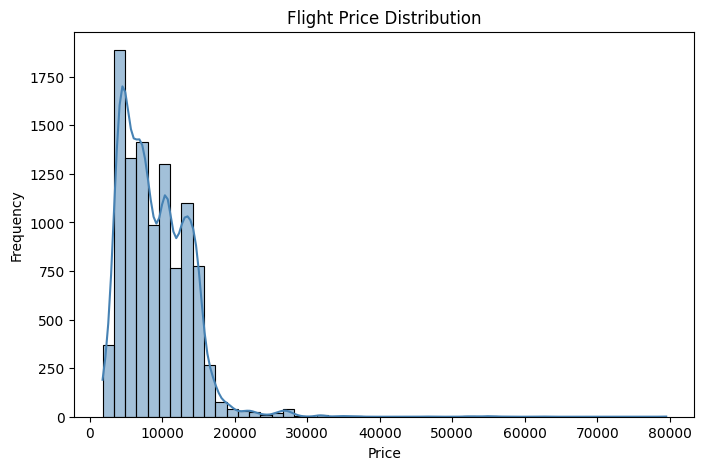

In [16]:
# Check the distribution of the target variable (Price)
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True, bins=50, color="steelblue")
plt.title("Flight Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# View summary statistics of numerical features
summary = df.describe().T
summary["Range"] = summary["max"] - summary["min"]
summary

,count,mean,std,min,25%,50%,75%,max,Range
Price,10462.0,9026.790289,4624.849541,1759.0,5224.0,8266.0,12344.75,79512.0,77753.0


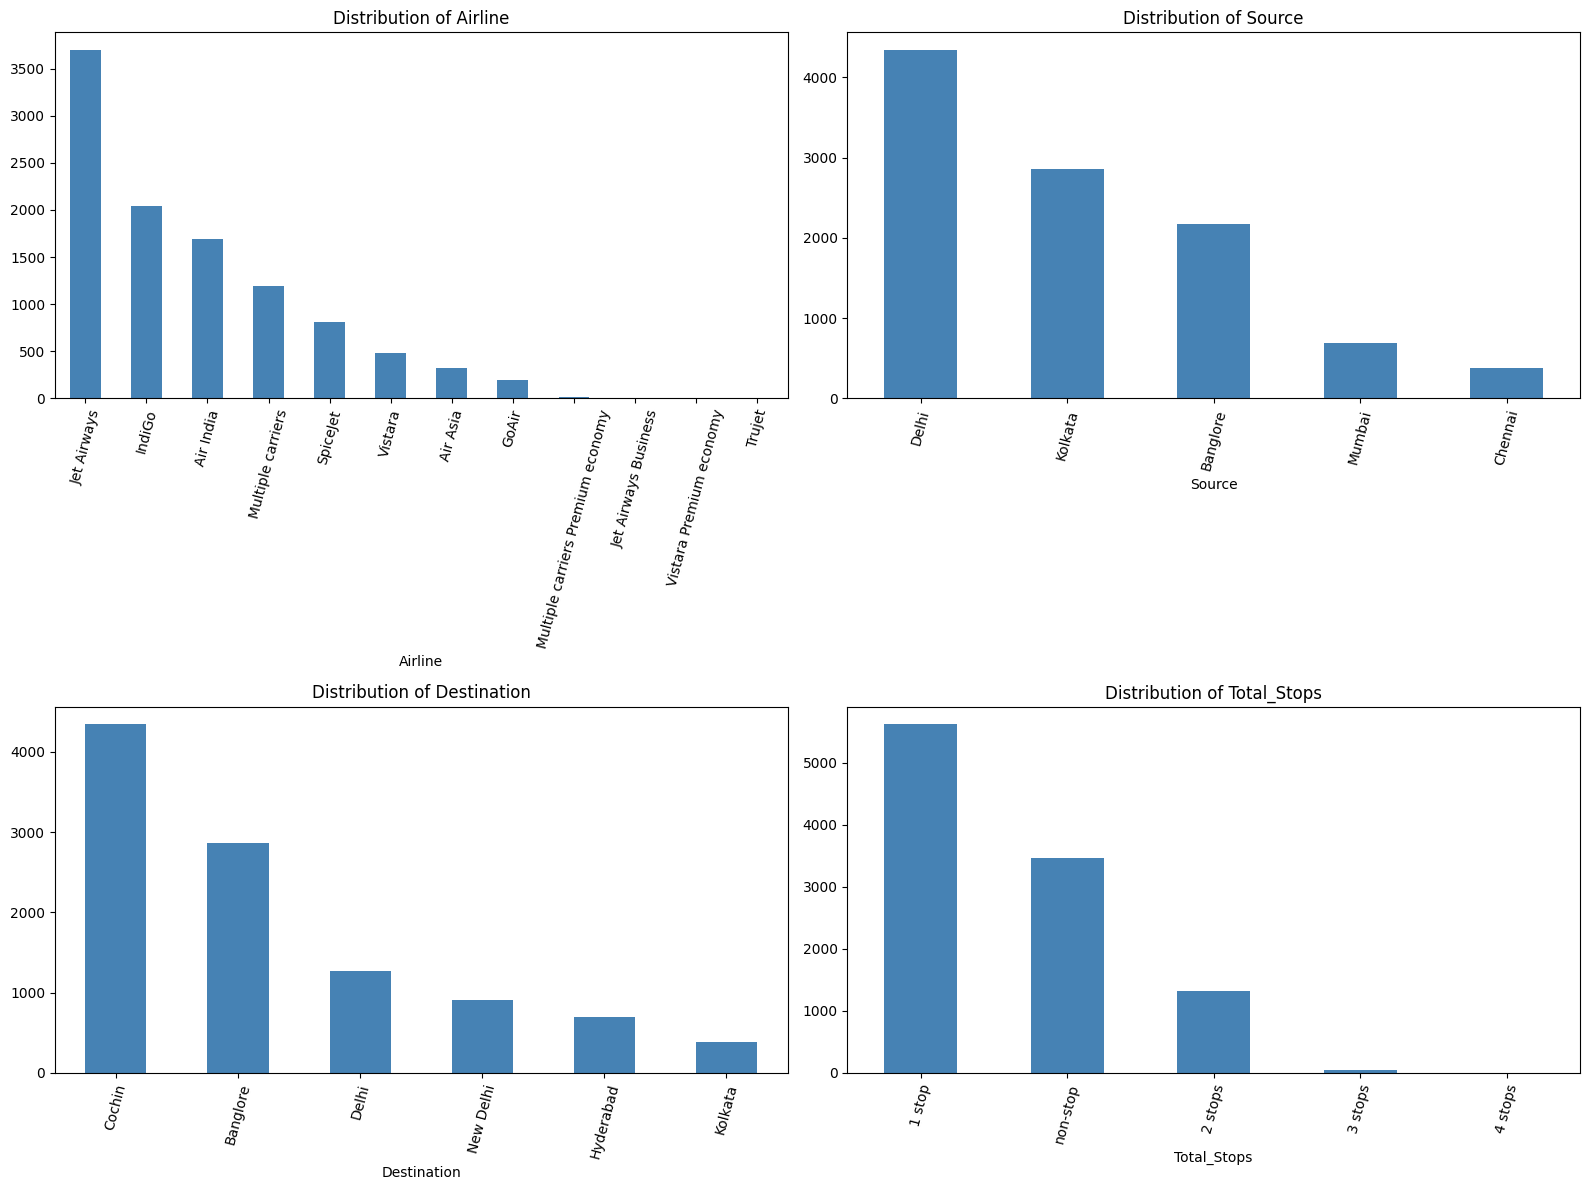

In [17]:
# Visualize the distribution of the categorical features
key_features = ['Airline', 'Source', 'Destination', 'Total_Stops']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, col in zip(axes.flatten(), key_features):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

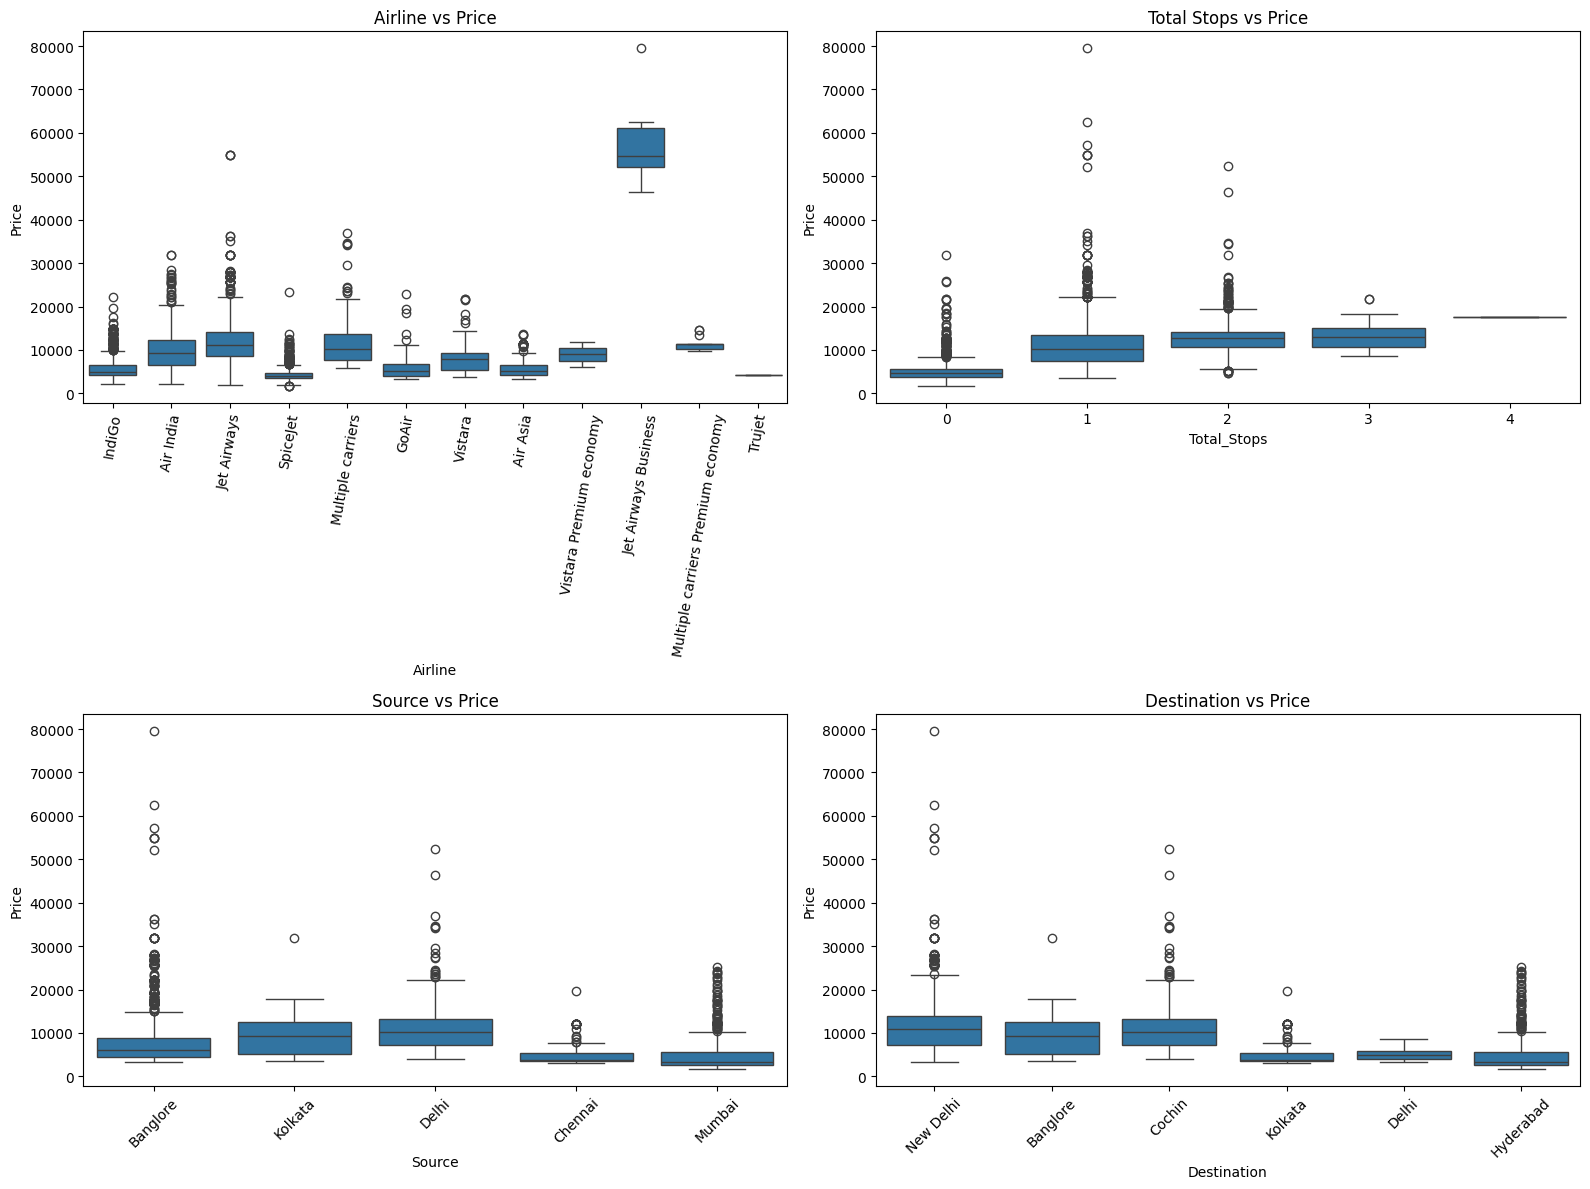

In [71]:
# Bivariate analysis — how key features relate to Price
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(x='Airline', y='Price', data=df, ax=axes[0,0])
axes[0,0].set_title('Airline vs Price')
axes[0,0].tick_params(axis='x', rotation=80)

sns.boxplot(x='Total_Stops', y='Price', data=df, ax=axes[0,1])
axes[0,1].set_title('Total Stops vs Price')

sns.boxplot(x='Source', y='Price', data=df, ax=axes[1,0])
axes[1,0].set_title('Source vs Price')
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(x='Destination', y='Price', data=df, ax=axes[1,1])
axes[1,1].set_title('Destination vs Price')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

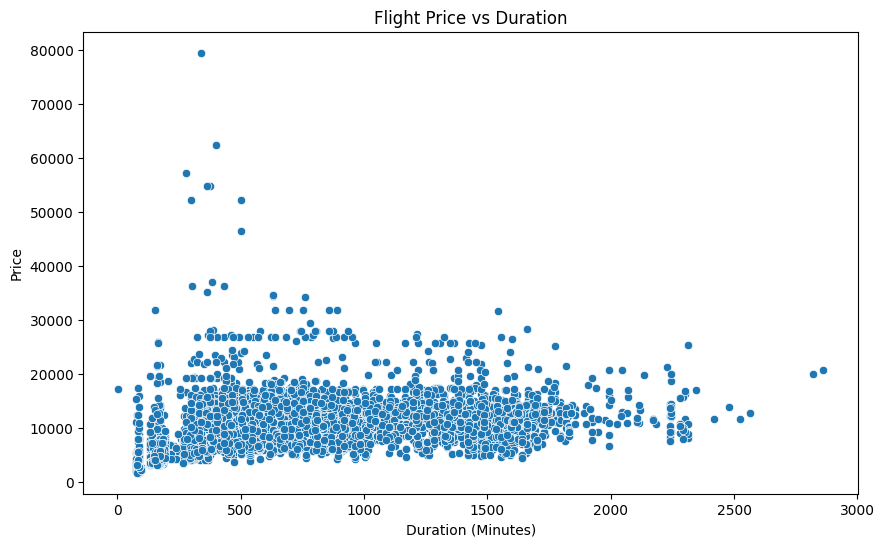

In [85]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Duration_mins', y='Price')

plt.title('Flight Price vs Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Price')

plt.show()


### Bivariate Analysis — Conclusion

The bivariate analysis shows that flight fare varies across important flight characteristics such as Airline, Total_Stops, Source, Destination, and Duration. These relationships indicate that ticket prices are influenced by a combination of airline and journey-related factors rather than a single feature. Therefore, these variables provide useful information for building the flight fare prediction model.


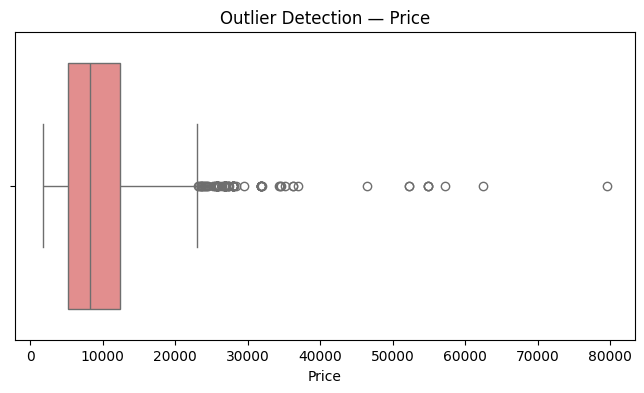

Number of outliers in Price (IQR method): 94


In [21]:
# Detect outliers in Price using a boxplot and the IQR rule
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Price'], color='lightcoral')
plt.title('Outlier Detection — Price')
plt.show()

q1, q3 = df['Price'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_count = ((df['Price'] < lower) | (df['Price'] > upper)).sum()
print(f"Number of outliers in Price (IQR method): {outlier_count}")

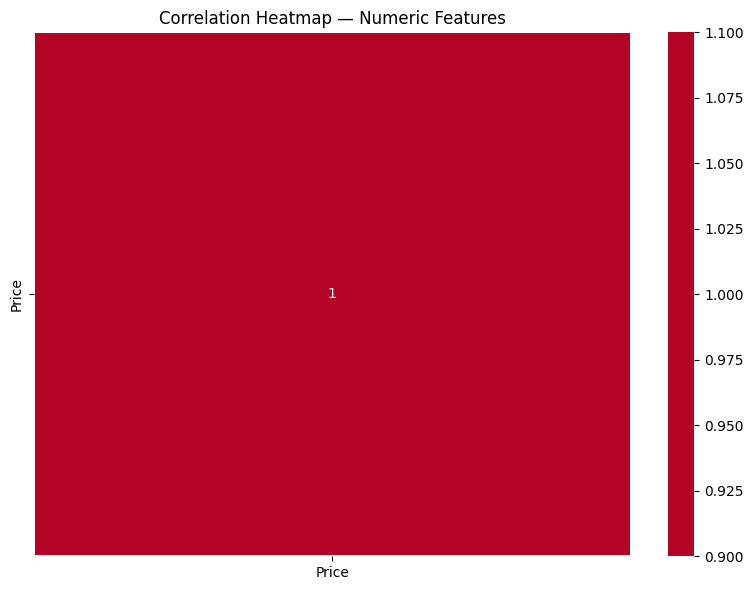

In [22]:
# Correlation heatmap — numeric features only (categorical features are encoded later)
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, linewidths=0.3)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

## **EDA Summary (Task 1 Conclusion):**

1. The dataset contains flight booking records with information about airline, route, journey timing, duration, and number of stops, providing relevant features for predicting flight fares.

2. After removing a small number of missing values and duplicate rows, the dataset is clean and suitable for machine learning model development.

3. The `Price` distribution is right-skewed, with most fares concentrated in the lower-to-middle range and a smaller number of high-fare bookings. This variation may be influenced by differences in airline, route, number of stops, journey duration, and travel timing.

4. Bivariate analysis shows that `Airline`, `Total_Stops`, `Source`, and `Destination` produce noticeable differences in the price distribution. This suggests that airline pricing patterns, route characteristics, and journey structure may contribute to variations in flight fares, making these features informative for the prediction model.

5. The correlation analysis provides an initial understanding of relationships among numerical variables. However, correlation alone may not capture nonlinear relationships or the influence of categorical features, so other analyses and model-based feature importance are also considered.

6. Outlier analysis identified some high-fare values using the IQR method. These observations were retained because they may represent valid premium or long-haul bookings rather than data-entry errors. Removing them could cause the model to underestimate legitimate high-priced flight fares.

7. Overall, the EDA indicates that flight fares are influenced by multiple flight and journey characteristics rather than a single feature. These findings provide a basis for feature engineering and the development of multiple regression models.


## **6. Data Preparation for Modelling (Task 2)**

###**Feature Engineering**

The raw Date_of_Journey, Dep_Time, Arrival_Time, and Duration columns are text and cannot be used directly by regression algorithms, so they are converted into numeric features (journey day/month, departure/arrival hour and minute, and duration in minutes). Total_Stops is converted into an ordinal number, and Route / Additional_Info are dropped as explained in the Challenges section.

###**Train / Test Split**

Split the data into training and test sets, and scale features for the algorithms that are sensitive to feature scale (Linear Regression, KNN, SVR). Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are scale-invariant and use the raw features directly.

In [23]:
# Extract Journey day and month
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df['Journey_day'] = df['Date_of_Journey'].dt.day
df['Journey_month'] = df['Date_of_Journey'].dt.month
df.drop('Date_of_Journey', axis=1, inplace=True)

# Extract Departure hour and minute
df['Dep_hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_min'] = pd.to_datetime(df['Dep_Time']).dt.minute
df.drop('Dep_Time', axis=1, inplace=True)

# Extract Arrival hour and minute (strip any trailing date text first, e.g. "04:25 10 Jun")
df['Arrival_Time'] = df['Arrival_Time'].apply(lambda x: x.split(' ')[0])
df['Arrival_hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_min'] = pd.to_datetime(df['Arrival_Time']).dt.minute
df.drop('Arrival_Time', axis=1, inplace=True)

# Convert Duration text (e.g. "2h 50m") into total minutes
def duration_to_minutes(duration):
    duration = duration.strip()
    hours, minutes = 0, 0
    if 'h' in duration:
        hours = int(duration.split('h')[0].strip())
        duration = duration.split('h')[1].strip()
    if 'm' in duration:
        minutes = int(duration.replace('m', '').strip())
    return hours * 60 + minutes

df['Duration_mins'] = df['Duration'].apply(duration_to_minutes)
df.drop('Duration', axis=1, inplace=True)

# Encode Total_Stops as an ordinal number (it has a natural order)
stops_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Total_Stops'] = df['Total_Stops'].map(stops_map)

# Drop Route (redundant with Source/Destination/Total_Stops, very high cardinality)
# and Additional_Info (dominated by a single value, low signal)
df.drop(['Route', 'Additional_Info'], axis=1, inplace=True)

df.head()

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_mins
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,10,170
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,15,445
2,Jet Airways,Delhi,Cochin,2,13882,9,6,9,25,4,25,1140
3,IndiGo,Kolkata,Banglore,1,6218,12,5,18,5,23,30,325
4,IndiGo,Banglore,New Delhi,1,13302,1,3,16,50,21,35,285


In [24]:
# One-hot encode the remaining nominal categorical features
df_encoded = pd.get_dummies(df, columns=['Airline', 'Source', 'Destination'], drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (10462, 29)


,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_mins,Airline_Air India,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,22,20,1,10,170,False,...,False,False,False,False,False,False,False,False,False,True
1,2,7662,1,5,5,50,13,15,445,True,...,False,False,False,True,False,False,False,False,False,False
2,2,13882,9,6,9,25,4,25,1140,False,...,False,False,True,False,False,True,False,False,False,False
3,1,6218,12,5,18,5,23,30,325,False,...,False,False,False,True,False,False,False,False,False,False
4,1,13302,1,3,16,50,21,35,285,False,...,False,False,False,False,False,False,False,False,False,True


In [25]:
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Store model results
results = {}
trained_models = {}

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 8369, Test samples: 2093


### Data Leakage Prevention

The dataset was first divided into training and testing sets before applying feature scaling. The StandardScaler was fitted only on the training data using `X_train`, and the fitted scaler was then used to transform `X_test`.

Therefore, information from the test dataset was not used to calculate the scaling parameters during model training. The test set remains unseen during the training process, ensuring a fair evaluation of model performance on unseen data.


## **7. Model Building & Training**

To predict flight fares, multiple machine learning regression algorithms are trained and evaluated. Instead of relying on a single model, six different regressors are developed and compared to identify the most accurate and reliable model for this task. This approach satisfies the Model Comparison Report requirement and helps select the most suitable model for production deployment.

**1.Model 1 — Linear Regression** — a simple baseline regression model that fits a straight-line relationship between features and price.

**2.Model 2 — Decision Tree Regressor** — a tree-based model that learns decision rules from flight booking details.

**3.Model 3 — Random Forest Regressor** — an ensemble model that combines multiple decision trees to improve accuracy and reduce overfitting.

**4.Model 4 — K-Nearest Neighbors (KNN) Regressor** — a distance-based algorithm that estimates price from similar nearby flights.

**5.Model 5 — Support Vector Regressor (SVR)** — a margin-based regressor that tries to fit prices within an error tolerance band.

**6.Model 6 — Gradient Boosting Regressor** — an ensemble boosting algorithm that builds decision trees sequentially to achieve high predictive performance.

###**7.1 Model 1 - Linear Regression**

In [26]:
model_name = 'Linear Regression'

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
preds = lin_reg.predict(X_test_scaled)

results[model_name] = {
    'MAE': mean_absolute_error(y_test, preds),
    'MSE': mean_squared_error(y_test, preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
    'R2 Score': r2_score(y_test, preds),
}
trained_models[model_name] = lin_reg

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))

--- Linear Regression ---
MAE         1.998639e+03
MSE         8.677715e+06
RMSE        2.945796e+03
R2 Score    5.838000e-01
dtype: float64


**Cross-Validation for Linear Regression**

In [39]:
from sklearn.model_selection import cross_val_score

lr_cv = cross_val_score(
    lin_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Linear Regression CV R2 Scores:", lr_cv)
print("Mean CV R2:", lr_cv.mean())

Linear Regression CV R2 Scores: [0.66418159 0.6364782  0.6646655  0.5775253  0.59229824]
Mean CV R2: 0.6270297631162969


###**7.2 Model 2 - Decision Tree Regressor**

In [27]:
model_name = 'Decision Tree'

dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)
preds = dt_reg.predict(X_test)

results[model_name] = {
    'MAE': mean_absolute_error(y_test, preds),
    'MSE': mean_squared_error(y_test, preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
    'R2 Score': r2_score(y_test, preds),
}
trained_models[model_name] = dt_reg

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))

--- Decision Tree ---
MAE         1.383087e+03
MSE         5.950313e+06
RMSE        2.439326e+03
R2 Score    7.146000e-01
dtype: float64


**Cross-Validation for Decision Tree**

In [44]:
dt_cv = cross_val_score(
    dt_reg,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)
print("Decision Tree  CV R2 Scores:", dt_cv)
print("Decision Tree Mean CV R2:", dt_cv.mean())

Decision Tree  CV R2 Scores: [0.7320895  0.73800347 0.73343182 0.73048379 0.71119973]
Decision Tree Mean CV R2: 0.729041660890114


###**7.3 Model 3 - Random Forest Regressor**

In [28]:
model_name = 'Random Forest'

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
preds = rf_reg.predict(X_test)

results[model_name] = {
    'MAE': mean_absolute_error(y_test, preds),
    'MSE': mean_squared_error(y_test, preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
    'R2 Score': r2_score(y_test, preds),
}
trained_models[model_name] = rf_reg

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))

--- Random Forest ---
MAE         1.168995e+03
MSE         3.861087e+06
RMSE        1.964965e+03
R2 Score    8.148000e-01
dtype: float64


**Cross-Validation for Random Forest**

In [41]:
rf_cv = cross_val_score(
    rf_reg,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Random Forest CV R2 Scores:", rf_cv)
print("Mean CV R2:", rf_cv.mean())

Random Forest CV R2 Scores: [0.80355278 0.81881638 0.8316342  0.81556226 0.79793463]
Mean CV R2: 0.8135000502715162


###**7.4 Model 4 - K-Nearest Neighbours (KNN) Regressor**

In [29]:
model_name = 'KNN'

knn_reg = KNeighborsRegressor(n_neighbors=7)
knn_reg.fit(X_train_scaled, y_train)
preds = knn_reg.predict(X_test_scaled)

results[model_name] = {
    'MAE': mean_absolute_error(y_test, preds),
    'MSE': mean_squared_error(y_test, preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
    'R2 Score': r2_score(y_test, preds),
}
trained_models[model_name] = knn_reg

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))

--- KNN ---
MAE         1.393159e+03
MSE         5.184467e+06
RMSE        2.276943e+03
R2 Score    7.513000e-01
dtype: float64


**Cross-Validation for KNN**

In [45]:
knn_cv = cross_val_score(
    knn_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)
print("KNN Mean CV R2 Scores:", knn_cv)
print("KNN Mean CV R2:", knn_cv.mean())

KNN Mean CV R2 Scores: [0.75984175 0.76475794 0.75374667 0.70080467 0.71624637]
KNN Mean CV R2: 0.7390794801905592


###**7.5 Model 5 - Support Vector Regressor (SVR)**

In [30]:
model_name = 'SVR'

svr_reg = SVR(kernel='rbf')
svr_reg.fit(X_train_scaled, y_train)
preds = svr_reg.predict(X_test_scaled)

results[model_name] = {
    'MAE': mean_absolute_error(y_test, preds),
    'MSE': mean_squared_error(y_test, preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
    'R2 Score': r2_score(y_test, preds),
}
trained_models[model_name] = svr_reg

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))

--- SVR ---
MAE         3.364935e+03
MSE         1.943241e+07
RMSE        4.408221e+03
R2 Score    6.800000e-02
dtype: float64


**Cross-Validation for SVR**

In [46]:
svr_cv = cross_val_score(
    svr_reg,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)
print("SVR Mean CV R2 Scores:", svr_cv)
print("SVR Mean CV R2:", svr_cv.mean())

SVR Mean CV R2 Scores: [0.03621502 0.04484846 0.03318426 0.03601087 0.05665873]
SVR Mean CV R2: 0.04138346711116676


###**7.6 Model 6 - Gradient Boosting Regressor**

In [31]:
model_name = 'Gradient Boosting'

gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train, y_train)
preds = gb_reg.predict(X_test)

results[model_name] = {
    'MAE': mean_absolute_error(y_test, preds),
    'MSE': mean_squared_error(y_test, preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
    'R2 Score': r2_score(y_test, preds),
}
trained_models[model_name] = gb_reg

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))

--- Gradient Boosting ---
MAE         1.536821e+03
MSE         5.143653e+06
RMSE        2.267962e+03
R2 Score    7.533000e-01
dtype: float64


**Cross-Validation for Gradient Boosting**

In [49]:
gb_cv = cross_val_score(
    gb_reg,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Gradient Boosting CV R2 Scores:", gb_cv)
print("Mean CV R2:", gb_cv.mean())

Gradient Boosting CV R2 Scores: [0.80406167 0.77754803 0.78849808 0.73734252 0.72632891]
Mean CV R2: 0.7667558410456716


## **8. Hyperparameter Tuning**

Hyperparameter tuning is performed to improve model performance by finding the best combination of model parameters. GridSearchCV is used with cross-validation to systematically evaluate different parameter combinations.

In this project, hyperparameter tuning is applied to the ensemble models, Random Forest and Gradient Boosting. The tuned models are evaluated on the unseen test dataset and compared with their respective baseline models to determine whether tuning improves predictive performance.

###**8.1 Hyperparameter Tuning - Random Forest Regressor**


In [50]:
# Hyperparameter Tuning - Random Forest Regressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation R2 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross Validation R2 Score: 0.8136205612292017


In [51]:
#Evaluate the Tuned Model
# Predict using the tuned model
y_pred = best_rf.predict(X_test)

# Performance Metrics
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1129.2493153467062
MSE: 3549541.4502361305
RMSE: 1884.0226777393445
R2 Score: 0.8297604604418063


In [52]:
# Update results with the tuned Random Forest model

results["Random Forest (Tuned)"] = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "R2 Score": r2_score(y_test, y_pred)
}
trained_models["Random Forest (Tuned)"] = best_rf

### **8.2 Hyperparameter Tuning — Gradient Boosting**

In [56]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

gb_grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

gb_grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(gb_grid_search.best_params_)

print("Best CV R2:")
print(gb_grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2:
0.8303602607789695


In [57]:
best_gb = gb_grid_search.best_estimator_

print(best_gb)

GradientBoostingRegressor(max_depth=5, n_estimators=200, random_state=42)


In [58]:
#evaluation
gb_pred = best_gb.predict(X_test)

gb_tuned_results = {
    "MAE": mean_absolute_error(y_test, gb_pred),
    "MSE": mean_squared_error(y_test, gb_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, gb_pred)),
    "R2 Score": r2_score(y_test, gb_pred)
}

print("--- Gradient Boosting (Tuned) ---")
print(pd.Series(gb_tuned_results).round(4))

--- Gradient Boosting (Tuned) ---
MAE         1.192412e+03
MSE         3.353049e+06
RMSE        1.831133e+03
R2 Score    8.392000e-01
dtype: float64


In [60]:
# Update results with the tuned Gradient Boosting model

results["Gradient Boosting (Tuned)"] = {
    "MAE": mean_absolute_error(y_test, gb_pred),
    "MSE": mean_squared_error(y_test, gb_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, gb_pred)),
    "R2 Score": r2_score(y_test, gb_pred)
}

trained_models["Gradient Boosting (Tuned)"] = best_gb

In [61]:
# Updated model comparison table

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="R2 Score", ascending=False)

results_df

,MAE,MSE,RMSE,R2 Score
Gradient Boosting (Tuned),1192.411677,3.353049e+06,1831.133383,0.839184
Random Forest (Tuned),1129.249315,3.549541e+06,1884.022678,0.829760
Random Forest,1168.995238,3.861087e+06,1964.964854,0.814818
Gradient Boosting,1536.820894,5.143653e+06,2267.962245,0.753305
KNN,1393.159238,5.184467e+06,2276.942504,0.751348
Decision Tree,1383.087235,5.950313e+06,2439.326357,0.714617
Linear Regression,1998.639306,8.677715e+06,2945.796236,0.583808
SVR,3364.934714,1.943241e+07,4408.221019,0.068002


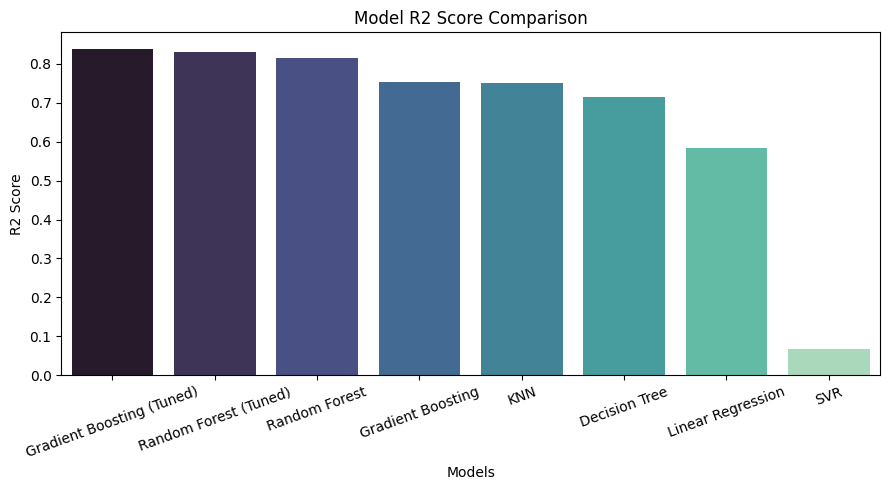

In [62]:
#Update the Comparison Chart
plt.figure(figsize=(9,5))

sns.barplot(
    data=results_df.reset_index(),
    x="index",
    y="R2 Score",
    palette="mako"
)

plt.title("Model R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## **9. Model Comparison Report**

After training and evaluating all eight regression models (six base models, tuned Random Forest, and tuned Gradient Boosting), their performance is compared using evaluation metrics such as MAE, MSE, RMSE, and R² Score. This comparison helps identify the model that provides the best predictive performance and generalization ability. Based on the results, Gradient Boosting (Tuned) was selected as the best-performing model and final model for flight fare prediction. Its strong R² Score and low RMSE indicate that it provides a good balance between explaining fare variation and minimizing prediction errors.

In [63]:
#Side-by-side metrics table
scaled_models = {'Linear Regression', 'KNN', 'SVR'}

results_df = pd.DataFrame(results).T.sort_values('R2 Score', ascending=False)
results_df.round(4)

,MAE,MSE,RMSE,R2 Score
Gradient Boosting (Tuned),1192.4117,3.353049e+06,1831.1334,0.8392
Random Forest (Tuned),1129.2493,3.549541e+06,1884.0227,0.8298
Random Forest,1168.9952,3.861087e+06,1964.9649,0.8148
Gradient Boosting,1536.8209,5.143653e+06,2267.9622,0.7533
KNN,1393.1592,5.184467e+06,2276.9425,0.7513
Decision Tree,1383.0872,5.950313e+06,2439.3264,0.7146
Linear Regression,1998.6393,8.677715e+06,2945.7962,0.5838
SVR,3364.9347,1.943241e+07,4408.2210,0.0680


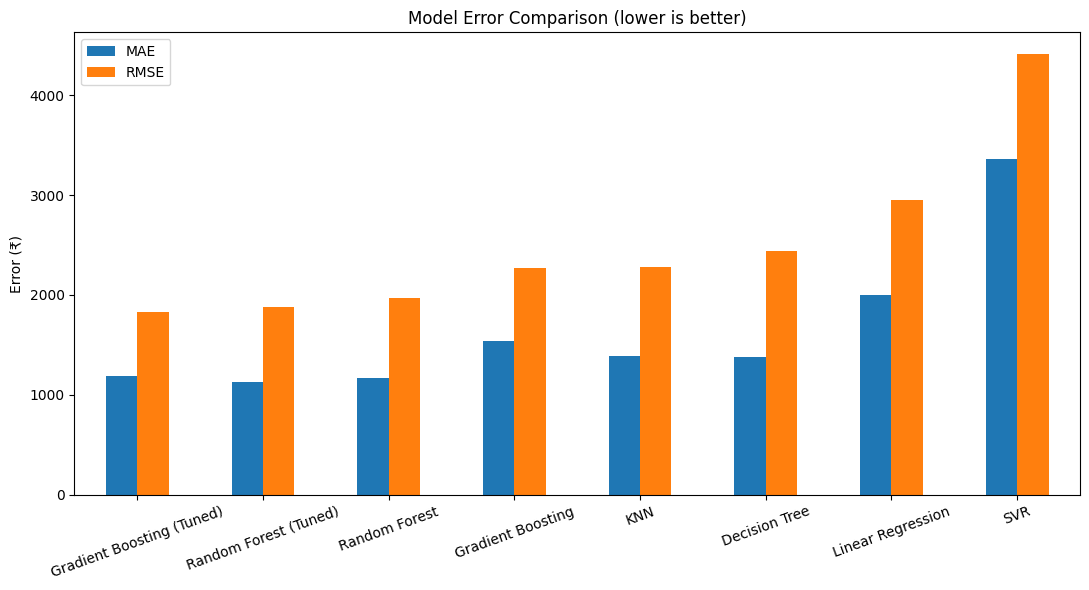

In [64]:
#Visual comparison of models
fig, ax = plt.subplots(figsize=(11, 6))
results_df[['MAE', 'RMSE']].plot(kind='bar', ax=ax)
ax.set_title('Model Error Comparison (lower is better)')
ax.set_ylabel('Error (₹)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [65]:
# Best model summary

best_model_name = results_df['R2 Score'].idxmax()

if best_model_name == "Random Forest (Tuned)":
    best_model = best_rf
    X_eval_best = X_test
else:
    best_model = trained_models[best_model_name]
    X_eval_best = X_test_scaled if best_model_name in scaled_models else X_test

best_preds = best_model.predict(X_eval_best)

print(f"Best Performing Model: {best_model_name}\n")
print("MAE:", mean_absolute_error(y_test, best_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_preds)))
print("R2 Score:", r2_score(y_test, best_preds))

Best Performing Model: Gradient Boosting (Tuned)

MAE: 1192.4116771032895
RMSE: 1831.1333833261997
R2 Score: 0.8391844114313802


### **Discussion & Recommendation**

**1. Which model performed best?**

Gradient Boosting (Tuned) was the best-performing model, achieving the highest R² Score of 0.8392 and the lowest RMSE of 1831.13 among all evaluated models.

**2. Why did Gradient Boosting perform best?**

Gradient Boosting was able to capture complex and non-linear relationships between flight-related features and ticket prices. Its boosting approach builds models sequentially, allowing later trees to improve the errors made by earlier trees.

**3. Did hyperparameter tuning improve the model?**

Yes. The baseline Gradient Boosting model achieved an R² Score of 0.7533, while the tuned Gradient Boosting model achieved 0.8392. This shows that hyperparameter optimization significantly improved the model's predictive performance.

**4. How did it compare with Random Forest?**

Random Forest (Tuned) achieved a slightly lower R² Score of 0.8298 and a higher RMSE of 1884.02. Although Random Forest (Tuned) had a lower MAE, Gradient Boosting (Tuned) provided the better overall performance based on R² and RMSE.

**5. Recommendation**

Gradient Boosting (Tuned) was the best-performing model because it achieved the highest R² Score of 0.8392 and the lowest RMSE of 1831.13 among all evaluated models.

##**10. Feature Importance**

Feature Importance analysis is performed using the selected Gradient Boosting (Tuned) model to identify the flight booking features that contribute most to fare prediction. Features with higher importance scores have a greater influence on the model's predictions. This analysis helps understand the key factors affecting flight prices and provides useful insights for fare prediction.

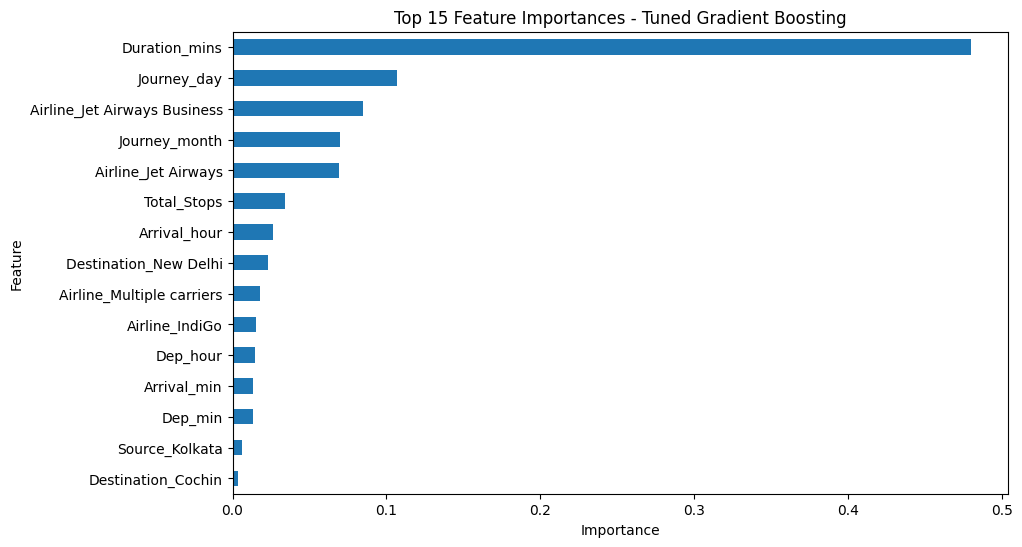

In [75]:
# Feature Importance from the selected model

gb_model = trained_models['Gradient Boosting (Tuned)']

importances = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

importances.head(15).sort_values().plot(kind='barh')

plt.title('Top 15 Feature Importances - Tuned Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [76]:
top_features = importances.head(4)
bottom_features = importances.tail(4)

print("Highly important features (biggest influence on price):")
print(top_features)
print("\nLeast important features (smallest influence on price):")
print(bottom_features)

Highly important features (biggest influence on price):
Duration_mins                   0.479743
Journey_day                     0.106618
Airline_Jet Airways Business    0.084987
Journey_month                   0.069778
dtype: float64

Least important features (smallest influence on price):
Destination_Delhi                  0.000181
Airline_Trujet                     0.000079
Airline_Vistara Premium economy    0.000036
Source_Chennai                     0.000034
dtype: float64


##**11. Model Testing on New Flight Details**

This section demonstrates the practical application of the trained machine learning model by predicting the fare for a brand-new, previously unseen flight booking.

In [79]:
# Model Testing on New Flight Details

# Build a new flight record with the same engineered feature set as X
new_flight = pd.DataFrame(0, index=[0], columns=X.columns)

new_flight['Total_Stops'] = 1
new_flight['Journey_day'] = 15
new_flight['Journey_month'] = 6
new_flight['Dep_hour'] = 9
new_flight['Dep_min'] = 30
new_flight['Arrival_hour'] = 13
new_flight['Arrival_min'] = 45
new_flight['Duration_mins'] = 255

# Set the relevant one-hot encoded columns to 1 (defaults to the baseline category if not found)
airline_col = 'Airline_Jet Airways'
source_col = 'Source_Delhi'
destination_col = 'Destination_Cochin'

for col in [airline_col, source_col, destination_col]:
    if col in new_flight.columns:
        new_flight[col] = 1

# Predict using the best Gradient Boosting (Tuned) model

best_model = trained_models['Gradient Boosting (Tuned)']

prediction = best_model.predict(new_flight)

print("Predicted Price: ₹{:.0f}".format(prediction[0]))

print("New Flight Details:")
print("Airline: Jet Airways | Source: Delhi | Destination: Cochin | Stops: 1 | Duration: 4h 15m")
print("\nFinal Predicted Price: ₹{:.0f}".format(prediction[0]))

Predicted Price: ₹8254
New Flight Details:
Airline: Jet Airways | Source: Delhi | Destination: Cochin | Stops: 1 | Duration: 4h 15m

Final Predicted Price: ₹8254


### **Task 2 Conclusion (Sections 6–11)**

1.The dataset was prepared through feature engineering (date/time/duration parsing, ordinal and one-hot encoding), then split into training and testing sets, with feature scaling applied where required.

2.Six machine learning regression models were trained and evaluated to predict flight fares based on booking details.

3.Hyperparameter tuning was performed on the ensemble models, Random Forest and Gradient Boosting. Gradient Boosting (Tuned) achieved the best overall performance and was selected as the final model.

4.The performance of all models was compared using MAE, MSE, RMSE, and R² Score, and the best model was selected based on these evaluation metrics.

5.Feature Importance analysis identified the flight details that have the greatest influence on predicting fare.

6.The selected Gradient Boosting (Tuned) model was tested on a new flight booking and successfully generated a predicted fare, demonstrating its practical application for flight fare prediction.

## **12. Challenges Faced**

**1. Understanding the Dataset**<br>
The dataset contains flight booking details in mixed text formats (dates, times, durations). Understanding the role of each feature was essential before performing data analysis and model building. This was addressed by reviewing the dataset description and conducting basic exploratory analysis.<br><br>

**2. Parsing Date, Time, and Duration Fields**<br>
Date_of_Journey, Dep_Time, Arrival_Time, and Duration were all stored as text (e.g. "24/03/2019", "2h 50m"), and Arrival_Time sometimes included a trailing date. These were parsed with `pandas.to_datetime` and a custom duration parser to extract numeric day/month/hour/minute/duration features.<br><br>

**3. High-Cardinality Route Column**<br>
The Route column had a very large number of unique values and was highly correlated with the existing Source, Destination, and Total_Stops columns. It was dropped to avoid exploding the feature space through one-hot encoding.<br><br>

**4. Feature Scaling**<br>
The dataset includes both continuous engineered features (such as Duration_mins) and one-hot encoded binary features. To ensure fair learning for distance/margin-based algorithms like Linear Regression, KNN, and SVR, feature scaling was performed using StandardScaler.<br><br>

**5. Selecting the Best Model**<br>
Different machine learning algorithms produced different prediction results. To identify the most suitable model, six regression algorithms were trained and compared using MAE, MSE, RMSE, and R² Score.<br><br>

**6. Hyperparameter Tuning**<br>
The default model parameters may not provide the best performance. GridSearchCV was used to optimize the hyperparameters of the ensemble models, Random Forest and Gradient Boosting, and compare their tuned performance with the baseline models.<br><br>

**7. Outliers in Price**<br>
Some very high fare values were present in the data. These were inspected using boxplots and the IQR method but were retained, since they represent valid premium or long-haul fares rather than data entry errors.<br><br>

**8. Avoiding Overfitting**<br>
Tree-based models can perform very well on training data but poorly on unseen data. This challenge was addressed by evaluating all models on a separate test dataset and selecting the model with the best generalization performance.<br><br>

**9. Interpreting Feature Importance**<br>
Identifying the booking details that most influence fare was essential for business understanding. The Gradient Boosting (Tuned) feature importance technique was used to determine the most significant features contributing to price prediction.<br><br>

**10. Why Gradient Boosting Was the Best-Performing Model**<br>

Gradient Boosting (Tuned) was selected as the best-performing model because it achieved the highest R² Score of 0.8392 and the lowest RMSE of 1831.13 among the evaluated models. Its strong performance indicates that it was able to capture complex relationships between flight-related features and ticket prices effectively.

The model's cross-validation performance was also considered to assess its consistency across different validation folds. Hyperparameter tuning significantly improved the Gradient Boosting model compared with its baseline version, increasing the R² Score from 0.7533 to 0.8392.

Therefore, Gradient Boosting (Tuned) was selected as the final model because it provided the best overall balance of predictive performance and generalization ability.

## **13. Final Conclusion**

**1.Project Objective:**

The primary objective of this project was to develop a machine learning model capable of predicting flight ticket fares based on booking details such as airline, route, duration, number of stops, and journey date.
<br><br>

**2.Exploratory Data Analysis (EDA):**

A comprehensive Exploratory Data Analysis (EDA) was conducted to understand the dataset by examining its structure, checking for missing values and duplicates, analysing the price distribution, identifying outliers, and exploring relationships between the features and the target variable.
<br><br>

**3.Model Development and Evaluation:**

Six machine learning regression models — Linear Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Support Vector Regressor (SVR), and Gradient Boosting — were trained, evaluated, and compared using MAE, MSE, RMSE, and R² Score to identify the best-performing model.
<br><br>

**4.Model Optimization:**

Hyperparameter tuning was applied to both Random Forest and Gradient Boosting. Gradient Boosting (Tuned) was selected as the final model because it achieved the highest R² Score of 0.8392 and the lowest RMSE of 1831.13 among all evaluated models. Its R² Score also improved from 0.7533 for the baseline Gradient Boosting model to 0.8392 after tuning.
<br><br>


**5.Feature Importance Analysis:**

Feature Importance analysis identified Total_Stops, Duration, Airline, and journey timing as the most influential factors affecting flight fare. These insights provide valuable information for both customers and travel businesses.
<br><br>

**6.Machine Learning Approach and Insights:**

The project also demonstrates the importance of proper data preprocessing, feature engineering, model selection, and evaluation techniques in developing reliable machine learning regression systems. The comparative analysis of multiple algorithms helped in understanding the strengths and performance of different approaches for solving real-world business problems.
<br><br>

**7.Conclusion:**

Overall, this project proves that machine learning can effectively support flight fare prediction, enabling customers and travel businesses to make data-driven booking and pricing decisions, reduce pricing errors, and improve planning around flight costs.
<br><br>

**8.Future Enhancements:**

Future enhancements can include integrating larger and more recent flight fare datasets, applying advanced ensemble/boosting techniques (e.g. XGBoost, LightGBM), incorporating additional real-world features such as seasonal demand and fuel prices, and deploying the optimized model as a web application or API for real-time fare prediction.

# **14. Project Links**

The following links provide access to the complete project resources, including the source code, dataset, trained models, presentation, and supporting documentation.

## **1. GitHub Repository**
Access the complete source code, Jupyter Notebook, README, and project files.

🔗 **GitHub Repository:**
https://github.com/Sameekshagithub/PRCP-1025-Flight-Fare-Price-Prediction-Using-Machine-Learning-Regression.git

---

## **2. Google Drive**
Access the PPT and REPORT.

🔗 **Google Drive:**
https://drive.google.com/drive/folders/1Hp_r_xMfYt7KTZ2XN35BsMCofUasQRBP?usp=drive_link

---